# Urban Network Embedded in Height Field with Mobility Flows

**Conceptual figure for physics poster**

This notebook generates a clean, poster-ready visualization showing:
- A synthetic height field (terrain)
- A regular grid network embedded in the terrain
- Mobility flows propagating over the network

In [179]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.collections import LineCollection
import matplotlib.cm as cm
from collections import deque

# Set random seed for reproducibility
np.random.seed(42)

## 1. Create the Grid Network

Build a 10×10 regular grid of nodes with integer coordinates.

In [180]:
# Grid parameters
GRID_SIZE = 5
nodes = []
node_positions = {}

# Create grid nodes
node_id = 0
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        nodes.append(node_id)
        node_positions[node_id] = (i, j)
        node_id += 1

# Create grid edges (horizontal and vertical connections)
edges = []
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        current = i * GRID_SIZE + j
        # Horizontal edge (to the right)
        if j < GRID_SIZE - 1:
            neighbor = i * GRID_SIZE + (j + 1)
            edges.append((current, neighbor))
        # Vertical edge (downward)
        if i < GRID_SIZE - 1:
            neighbor = (i + 1) * GRID_SIZE + j
            edges.append((current, neighbor))

print(f"Created grid network with {len(nodes)} nodes and {len(edges)} edges")

Created grid network with 25 nodes and 40 edges


In [181]:
def find_grid_path(origin, destination, grid_size):
    """
    Find a path on the grid from origin to destination using BFS.
    Returns list of node positions forming the path.
    """
    # Build adjacency list
    adj = {i: [] for i in range(grid_size * grid_size)}
    for i in range(grid_size):
        for j in range(grid_size):
            current = i * grid_size + j
            # Right neighbor
            if j < grid_size - 1:
                neighbor = i * grid_size + (j + 1)
                adj[current].append(neighbor)
                adj[neighbor].append(current)
            # Down neighbor
            if i < grid_size - 1:
                neighbor = (i + 1) * grid_size + j
                adj[current].append(neighbor)
                adj[neighbor].append(current)
    
    # BFS to find path
    queue = deque([(origin, [origin])])
    visited = {origin}
    
    while queue:
        node, path = queue.popleft()
        
        if node == destination:
            return path
        
        for neighbor in adj[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append((neighbor, path + [neighbor]))
    
    return [origin, destination]  # Fallback to direct if no path found

print("Pathfinding function created")

Pathfinding function created


## 1.5. Pathfinding on Grid

Create a function to find paths along the grid (following streets).

## 2. Generate Synthetic Height Field

Create a smooth height field combining:
- A global slope (valley effect)
- Two Gaussian hills

In [182]:
# Create high-resolution grid for smooth height field
resolution = 200
x = np.linspace(0, GRID_SIZE - 1, resolution)
y = np.linspace(0, GRID_SIZE - 1, resolution)
X, Y = np.meshgrid(x, y)

# 1. Global slope (creates a valley/hillside effect)
height = 0.3 * X + 0.2 * Y

# 2. Add Gaussian hill 1
center1_x, center1_y = 3.0, 3.5
sigma1 = 2.0
amplitude1 = 4.0
hill1 = amplitude1 * np.exp(-((X - center1_x)**2 + (Y - center1_y)**2) / (2 * sigma1**2))
height += hill1

# 3. Add Gaussian hill 2
center2_x, center2_y = 7.0, 6.0
sigma2 = 1.5
amplitude2 = 3.0
hill2 = amplitude2 * np.exp(-((X - center2_x)**2 + (Y - center2_y)**2) / (2 * sigma2**2))
height += hill2

print(f"Height field range: [{height.min():.2f}, {height.max():.2f}]")

Height field range: [0.28, 5.72]


## 3. Generate Mobility Flows

Create random origin-destination pairs with varying flow intensities.

In [183]:
# Generate 5 distinct mobility flows (both uphill and downhill)
# Use predefined origin-destination pairs in different regions of the grid
# OD pairs are computed based on GRID_SIZE to work with any grid dimension
# Uphill segments will be solid, downhill segments will be dashed

# Define candidate O-D pairs (node IDs) in different regions
# Node ID formula: node_id = row * GRID_SIZE + col
candidate_pairs = [
    (0 * GRID_SIZE + 1, (GRID_SIZE-1) * GRID_SIZE + (GRID_SIZE-2)),  # Bottom to top-right diagonal
    (0 * GRID_SIZE + 0, (GRID_SIZE//2) * GRID_SIZE + 0),              # Bottom-left to middle-left vertical
    (2 * GRID_SIZE + 0, 2 * GRID_SIZE + (GRID_SIZE-1)),              # Middle-left horizontal
    ((GRID_SIZE//2) * GRID_SIZE + (GRID_SIZE//2), (GRID_SIZE-1) * GRID_SIZE + (GRID_SIZE-1)),  # Center to top-right
    (0 * GRID_SIZE + (GRID_SIZE//2), (GRID_SIZE-1) * GRID_SIZE + (GRID_SIZE//2)),  # Bottom-center to top-center vertical
    (0 * GRID_SIZE + 0, (GRID_SIZE-1) * GRID_SIZE + (GRID_SIZE-1)),  # Bottom-left to top-right corner
    (1 * GRID_SIZE + 0, (GRID_SIZE-2) * GRID_SIZE + (GRID_SIZE-1)),  # Lower-left to upper-right
]

# Select first 5 valid pairs (no filtering by elevation)
od_pairs = []
for origin, destination in candidate_pairs:
    if origin >= len(node_positions) or destination >= len(node_positions):
        continue  # Skip if nodes don't exist
    od_pairs.append((origin, destination))
    if len(od_pairs) >= 5:
        break

print(f"Generated {len(od_pairs)} flows")

flows = []
for idx, (origin, destination) in enumerate(od_pairs):
    # Random flow intensity (log-normal distribution for variety)
    intensity = np.random.lognormal(mean=1.5, sigma=0.8)
    
    # Find path along the grid
    path = find_grid_path(origin, destination, GRID_SIZE)
    
    flows.append({
        'origin': origin,
        'destination': destination,
        'intensity': intensity,
        'path': path
    })

# Normalize intensities for visualization
max_intensity = max(f['intensity'] for f in flows)
for f in flows:
    f['intensity_norm'] = f['intensity'] / max_intensity

print(f"Generated {len(flows)} distinct mobility flows")
print("Flow paths:")
for idx, f in enumerate(flows):
    orig_pos = node_positions[f['origin']]
    dest_pos = node_positions[f['destination']]
    print(f"  Flow {idx+1}: {orig_pos} → {dest_pos} (length: {len(f['path'])} nodes)")

Generated 5 flows
Generated 5 distinct mobility flows
Flow paths:
  Flow 1: (0, 1) → (4, 3) (length: 7 nodes)
  Flow 2: (0, 0) → (2, 0) (length: 3 nodes)
  Flow 3: (2, 0) → (2, 4) (length: 5 nodes)
  Flow 4: (2, 2) → (4, 4) (length: 5 nodes)
  Flow 5: (0, 2) → (4, 2) (length: 5 nodes)


## 4. Create the Visualization

Combine all elements into a clean, poster-ready figure.

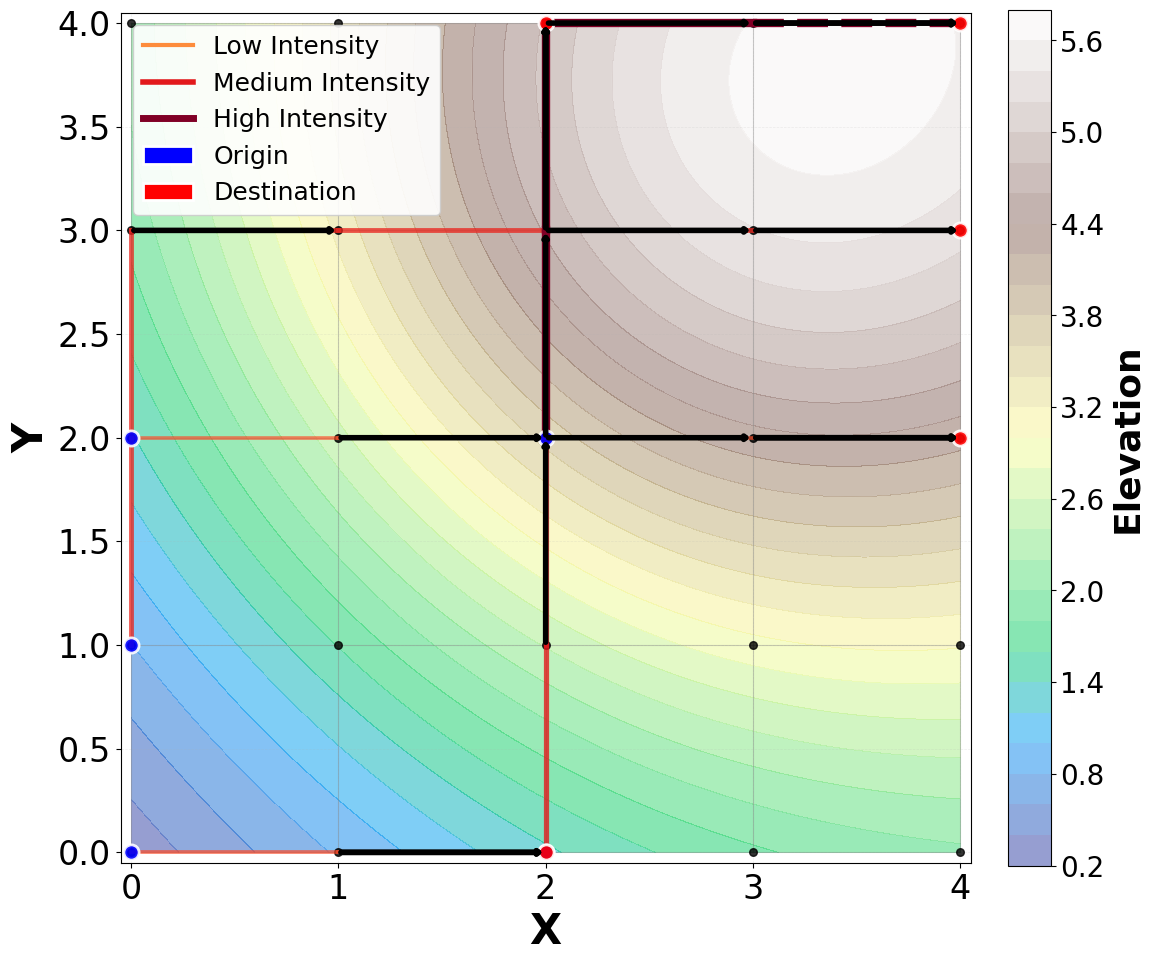

Figure generated successfully!


In [184]:
# Create figure with high DPI for poster quality
fig, ax = plt.subplots(figsize=(12, 12), dpi=100)

# 1. Plot height field as background
terrain_cmap = plt.cm.terrain
contour = ax.contourf(X, Y, height, levels=30, cmap=terrain_cmap, alpha=0.5)

# Add subtle contour lines
ax.contour(X, Y, height, levels=15, colors='white', alpha=0.2, linewidths=0.5)

# 2. Plot network edges
edge_segments = []
for u, v in edges:
    pos_u = node_positions[u]
    pos_v = node_positions[v]
    edge_segments.append([pos_u, pos_v])

edge_collection = LineCollection(
    edge_segments,
    colors='gray',
    linewidths=0.8,
    alpha=0.4,
    zorder=2
)
ax.add_collection(edge_collection)

# 3. Plot network nodes
node_x = [node_positions[n][0] for n in nodes]
node_y = [node_positions[n][1] for n in nodes]
ax.scatter(node_x, node_y, c='black', s=30, zorder=3, alpha=0.8)

# 3.5 Plot origin nodes (blue) and destination nodes (red)
origin_nodes = [f['origin'] for f in flows]
dest_nodes = [f['destination'] for f in flows]

origin_x = [node_positions[n][0] for n in origin_nodes]
origin_y = [node_positions[n][1] for n in origin_nodes]
ax.scatter(origin_x, origin_y, c='blue', s=120, zorder=5, alpha=0.9, edgecolors='white', linewidths=2)

dest_x = [node_positions[n][0] for n in dest_nodes]
dest_y = [node_positions[n][1] for n in dest_nodes]
ax.scatter(dest_x, dest_y, c='red', s=120, zorder=5, alpha=0.9, edgecolors='white', linewidths=2)

# 4. Plot mobility flows: solid for uphill, dashed for downhill
for flow in flows:
    path = flow['path']
    intensity = flow['intensity_norm']
    
    # Get path coordinates
    path_coords = [node_positions[node] for node in path]
    
    # Calculate arrow properties
    linewidth = 1.5 + 4.5 * intensity  # Scale linewidth with intensity
    alpha = 0.6 + 0.4 * intensity      # More intense flows are more opaque
    
    # Color from orange to red based on intensity
    color = plt.cm.YlOrRd(0.5 + 0.5 * intensity)
    
    # Draw path as connected segments, checking elevation for each segment
    for i in range(len(path_coords) - 1):
        start = path_coords[i]
        end = path_coords[i + 1]
        
        # Get elevation at start and end of segment
        start_i = int(start[0] / (GRID_SIZE - 1) * (resolution - 1))
        start_j = int(start[1] / (GRID_SIZE - 1) * (resolution - 1))
        end_i = int(end[0] / (GRID_SIZE - 1) * (resolution - 1))
        end_j = int(end[1] / (GRID_SIZE - 1) * (resolution - 1))
        
        start_elevation = height[start_j, start_i]
        end_elevation = height[end_j, end_i]
        
        # Determine line style: solid for uphill, dashed for downhill
        if end_elevation > start_elevation:
            linestyle = '-'  # Solid for uphill
        else:
            linestyle = '--'  # Dashed for downhill
        
        # Draw the line segment
        ax.plot([start[0], end[0]], [start[1], end[1]], 
               color=color, linewidth=linewidth, alpha=alpha, linestyle=linestyle, zorder=4)
    
    # Add directional arrows at regular intervals along the path
    # Use thick black arrows for maximum visibility
    arrow_interval = max(1, len(path_coords) // 3)  # ~3 arrows per path
    for i in range(arrow_interval, len(path_coords) - 1, arrow_interval):
        start = path_coords[i]
        end = path_coords[i + 1]
        
        # Large black arrow
        arrow = FancyArrowPatch(
            start, end,
            arrowstyle='->,head_width=1.2,head_length=1.5',
            color='black',
            linewidth=4,
            alpha=1.0,
            zorder=7
        )
        ax.add_patch(arrow)
    
    # Always add arrow at the end
    if len(path_coords) > 1:
        start = path_coords[-2]
        end = path_coords[-1]
        
        # Large black arrow
        arrow = FancyArrowPatch(
            start, end,
            arrowstyle='->,head_width=1.2,head_length=1.5',
            color='black',
            linewidth=4,
            alpha=1.0,
            zorder=7
        )
        ax.add_patch(arrow)

# 5. Styling - LARGER LABELS
ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(-0.5, GRID_SIZE - 0.5)
ax.set_aspect('equal')
ax.set_xlabel('X', fontsize=30, fontweight='bold')
ax.set_ylabel('Y', fontsize=30, fontweight='bold')

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=24)

# Add colorbar for height field
cbar = plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Elevation', fontsize=26, fontweight='bold')
cbar.ax.tick_params(labelsize=20)

# Add legend for flow intensity colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=plt.cm.YlOrRd(0.5), lw=3, label='Low Intensity'),
    Line2D([0], [0], color=plt.cm.YlOrRd(0.75), lw=4, label='Medium Intensity'),
    Line2D([0], [0], color=plt.cm.YlOrRd(1.0), lw=5, label='High Intensity'),
    Patch(facecolor='blue', edgecolor='white', label='Origin', linewidth=2),
    Patch(facecolor='red', edgecolor='white', label='Destination', linewidth=2)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=18, framealpha=0.9)

# Set exact axis limits with small margin
ax.set_xlim([-0.05, GRID_SIZE-1+0.05])
ax.set_ylim([-0.05, GRID_SIZE-1+0.05])

# Clean grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

plt.show()

print("Figure generated successfully!")

## 5. Export High-Resolution Figure

Save as 300 DPI PNG for poster printing.

Figure saved to ../output/urban_network_height_field_poster.png


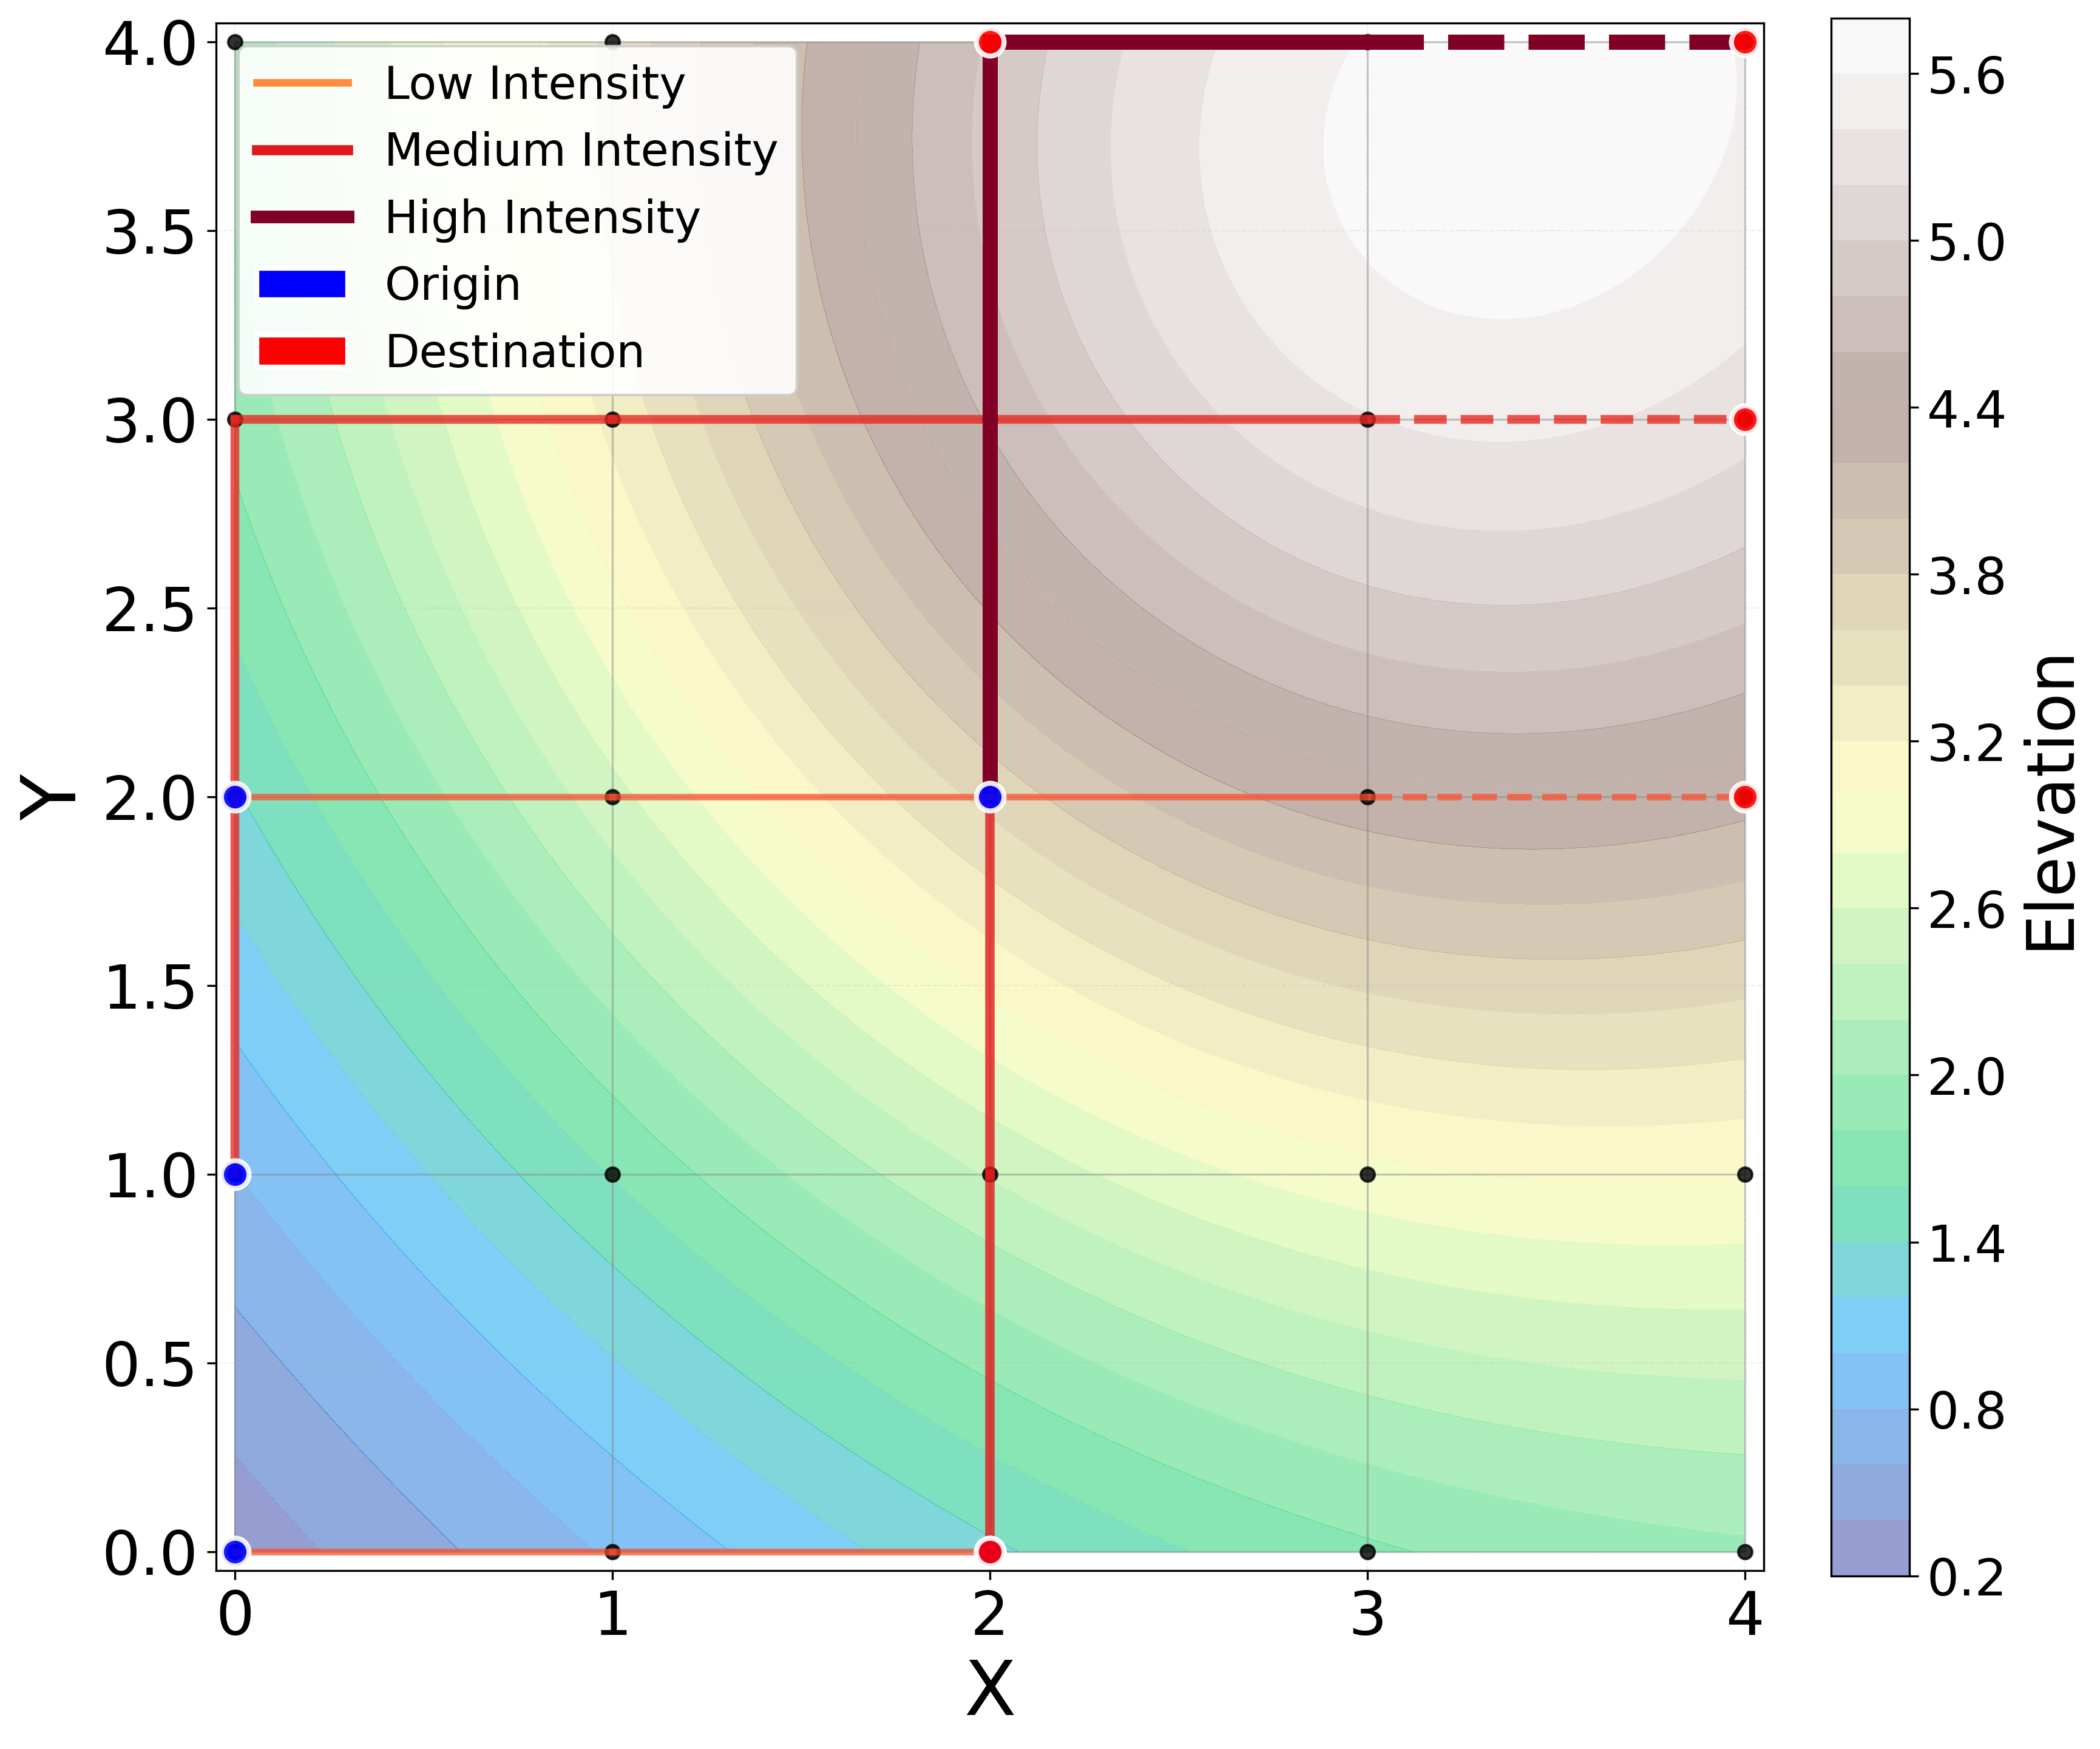

In [186]:
# Re-create figure with higher DPI for export
fig, ax = plt.subplots(figsize=(12, 12), dpi=300)

# 1. Plot height field as background
terrain_cmap = plt.cm.terrain
contour = ax.contourf(X, Y, height, levels=30, cmap=terrain_cmap, alpha=0.5)

# Add subtle contour lines
ax.contour(X, Y, height, levels=15, colors='white', alpha=0.2, linewidths=0.5)

# 2. Plot network edges
edge_segments = []
for u, v in edges:
    pos_u = node_positions[u]
    pos_v = node_positions[v]
    edge_segments.append([pos_u, pos_v])

edge_collection = LineCollection(
    edge_segments,
    colors='gray',
    linewidths=0.8,
    alpha=0.4,
    zorder=2
)
ax.add_collection(edge_collection)

# 3. Plot network nodes
node_x = [node_positions[n][0] for n in nodes]
node_y = [node_positions[n][1] for n in nodes]
ax.scatter(node_x, node_y, c='black', s=30, zorder=3, alpha=0.8)

# 3.5 Plot origin nodes (blue) and destination nodes (red)
origin_nodes = [f['origin'] for f in flows]
dest_nodes = [f['destination'] for f in flows]

origin_x = [node_positions[n][0] for n in origin_nodes]
origin_y = [node_positions[n][1] for n in origin_nodes]
ax.scatter(origin_x, origin_y, c='blue', s=120, zorder=5, alpha=0.9, edgecolors='white', linewidths=2)

dest_x = [node_positions[n][0] for n in dest_nodes]
dest_y = [node_positions[n][1] for n in dest_nodes]
ax.scatter(dest_x, dest_y, c='red', s=120, zorder=5, alpha=0.9, edgecolors='white', linewidths=2)

# 4. Plot mobility flows: solid for uphill, dashed for downhill
for flow in flows:
    path = flow['path']
    intensity = flow['intensity_norm']
    
    # Get path coordinates
    path_coords = [node_positions[node] for node in path]
    
    # Calculate arrow properties
    linewidth = 1.5 + 4.5 * intensity  # Scale linewidth with intensity
    alpha = 0.6 + 0.4 * intensity      # More intense flows are more opaque
    
    # Color from orange to red based on intensity
    color = plt.cm.YlOrRd(0.5 + 0.5 * intensity)
    
    # Draw path as connected segments, checking elevation for each segment
    for i in range(len(path_coords) - 1):
        start = path_coords[i]
        end = path_coords[i + 1]
        
        # Get elevation at start and end of segment
        start_i = int(start[0] / (GRID_SIZE - 1) * (resolution - 1))
        start_j = int(start[1] / (GRID_SIZE - 1) * (resolution - 1))
        end_i = int(end[0] / (GRID_SIZE - 1) * (resolution - 1))
        end_j = int(end[1] / (GRID_SIZE - 1) * (resolution - 1))
        
        start_elevation = height[start_j, start_i]
        end_elevation = height[end_j, end_i]
        
        # Determine line style: solid for uphill, dashed for downhill
        if end_elevation > start_elevation:
            linestyle = '-'  # Solid for uphill
        else:
            linestyle = '--'  # Dashed for downhill
        
        # Draw the line segment
        ax.plot([start[0], end[0]], [start[1], end[1]], 
               color=color, linewidth=linewidth, alpha=alpha, linestyle=linestyle, zorder=4)
    
    # Add directional arrows at regular intervals along the path
    # Use thick black arrows for maximum visibility
    arrow_interval = max(1, len(path_coords) // 3)  # ~3 arrows per path
    for i in range(arrow_interval, len(path_coords) - 1, arrow_interval):
        start = path_coords[i]
        end = path_coords[i + 1]
        
    #     # Large black arrow
    #     arrow = FancyArrowPatch(
    #         start, end,
    #         arrowstyle='->,head_width=1.2,head_length=1.5',
    #         color='black',
    #         linewidth=4,
    #         alpha=1.0,
    #         zorder=7
    #     )
    #     ax.add_patch(arrow)
    
    # # Always add arrow at the end
    # if len(path_coords) > 1:
    #     start = path_coords[-2]
    #     end = path_coords[-1]
        
    #     # Large black arrow
    #     arrow = FancyArrowPatch(
    #         start, end,
    #         arrowstyle='->,head_width=1.2,head_length=1.5',
    #         color='black',
    #         linewidth=4,
    #         alpha=1.0,
    #         zorder=7
    #     )
    #     ax.add_patch(arrow)

# 5. Styling - LARGER LABELS
ax.set_xlim(-0.5, GRID_SIZE - 0.5)
ax.set_ylim(-0.5, GRID_SIZE - 0.5)
ax.set_aspect('equal')
ax.set_xlabel('X', fontsize=30, fontweight='normal')
ax.set_ylabel('Y', fontsize=30, fontweight='normal')

# Increase tick label size
ax.tick_params(axis='both', which='major', labelsize=24)

# Add colorbar for height field
cbar = plt.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Elevation', fontsize=26, fontweight='normal')
cbar.ax.tick_params(labelsize=20)

# Add legend for flow intensity colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

legend_elements = [
    Line2D([0], [0], color=plt.cm.YlOrRd(0.5), lw=3, label='Low Intensity'),
    Line2D([0], [0], color=plt.cm.YlOrRd(0.75), lw=4, label='Medium Intensity'),
    Line2D([0], [0], color=plt.cm.YlOrRd(1.0), lw=5, label='High Intensity'),
    Patch(facecolor='blue', edgecolor='white', label='Origin', linewidth=2),
    Patch(facecolor='red', edgecolor='white', label='Destination', linewidth=2)
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=18, framealpha=0.9)

# Set exact axis limits with small margin
ax.set_xlim([-0.05, GRID_SIZE-1+0.05])
ax.set_ylim([-0.05, GRID_SIZE-1+0.05])

# Clean grid
ax.grid(True, alpha=0.2, linestyle='--', linewidth=0.5)

# Save to file
output_path = '../output/urban_network_height_field_poster.png'
plt.savefig(output_path, dpi=300, pad_inches=0)
print(f"Figure saved to {output_path}")

## Summary

**Generated figure components:**
- ✓ 10×10 regular grid network (100 nodes, 180 edges)
- ✓ Smooth synthetic height field (global slope + 2 Gaussian hills)
- ✓ Network embedded in terrain (nodes and edges)
- ✓ **5 mobility flows following grid streets** (not curved, following the network like real streets)
- ✓ **Larger labels** for poster readability
- ✓ Poster-ready quality (300 DPI PNG)

**File saved to:** `../output/urban_network_height_field_poster.png`

The figure is now ready for use in scientific posters or presentations.